# NHS A&E Patient Flow Analysis (2025–2026)

## Project Overview

This project analyses NHS England Accident & Emergency (A&E) operational performance data from April 2025 to March 2026.

The analysis focuses on:
- Monthly A&E demand trends
- 4-hour A&E performance
- Decision-to-admit (DTA) waiting times
- Provider-level performance variation
- Indicators of wider patient-flow pressure across NHS hospitals

The project uses publicly available NHS England monthly A&E Attendances and Emergency Admissions data at provider organisation level.

## Project Objectives

The objectives of this project are to:

1. Analyse monthly trends in A&E attendances and 4-hour performance
2. Explore the relationship between demand and operational performance
3. Identify providers with higher operational pressure
4. Investigate decision-to-admit waiting times as an indicator of patient-flow challenges
5. Produce healthcare-focused operational insights using real NHS England data

## Dataset

Source:
- NHS England — A&E Attendances and Emergency Admissions Dataset

Coverage:
- April 2025 to March 2026
- Provider-level NHS England data
- All A&E department types, including Minor Injury Units and Walk-in Centres

Key metrics used:
- Total A&E attendances
- Attendances over 4 hours
- 4-hour performance rate
- Decision-to-admit waits (4–12 hours and 12+ hours)

## Why This Project Matters

A&E waiting times and delayed admissions remain major operational challenges for the NHS. High emergency demand, bed pressures, discharge delays and wider hospital flow issues can contribute to longer waits for patients.

This project aims to explore these operational pressures using real NHS England performance data and demonstrate healthcare analytics techniques relevant to NHS operational and performance analysis roles.

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## Loading and Combining Monthly NHS A&E Datasets

In [2]:
file_paths = [
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_04.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_05.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_06.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_07.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_08.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_09.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_10.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_11.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_12.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2026_01.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2026_02.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2026_03.csv"
]

df_list = []

for file in file_paths:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

ae = pd.concat(df_list, ignore_index=True)

ae.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,Attendances over 4hrs Type 1,Attendances over 4hrs Type 2,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-APRIL-2025,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2350,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,MSitAE-APRIL-2025,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2333,0,0,0,0,0,49,0,0,0,0,0,0,0,0,0
2,MSitAE-APRIL-2025,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2528,0,0,0,0,0,58,0,0,0,0,0,0,0,0,0
3,MSitAE-APRIL-2025,Y02615,NHS ENGLAND MIDLANDS,SOUTH BIRMINGHAM GP WALK IN CENTRE,0,0,6628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,MSitAE-APRIL-2025,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3297,0,0,12,0,0,42,0,0,0,0,0,0,0,0,0


## Data Cleaning and Preparation

The raw NHS England monthly datasets were combined into a single dataframe before cleaning and preparation.

The data cleaning process included:
- Standardising column names
- Removing summary rows such as national totals
- Creating date variables
- Creating operational performance metrics
- Preparing provider-level and monthly-level analytical variables

This step is important to ensure consistent analysis across all 12 monthly datasets.

In [3]:
# Standardise column names
ae.columns = ae.columns.str.strip().str.lower().str.replace(" ", "_")

# Create a copy for cleaning
ae_clean = ae.copy()

# View dataframe shape
ae_clean.shape

(2397, 22)

### Creating Date Variables

In [5]:
# Clean period column
ae_clean["period_clean"] = (
    ae_clean["period"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Remove TOTAL rows
ae_clean = ae_clean[ae_clean["period_clean"] != "TOTAL"]

# Remove MSITAE- prefix
ae_clean["period_clean"] = (
    ae_clean["period_clean"]
    .str.replace("MSITAE-", "", regex=False)
)

# Convert to datetime
ae_clean["period_date"] = pd.to_datetime(
    ae_clean["period_clean"],
    format="%B-%Y"
)

# Create formatted month label
ae_clean["period_month"] = ae_clean["period_date"].dt.strftime("%b %Y")

# Preview
ae_clean[["period", "period_clean", "period_date", "period_month"]].head()

,period,period_clean,period_date,period_month
0,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
1,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
2,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
3,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
4,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025


## Creating Operational Performance Metrics

The NHS England A&E dataset includes total attendances and attendances over 4 hours.

Using these variables, additional operational performance metrics were created:
- 4-hour breach rate
- 4-hour performance rate
- Total decision-to-admit waits over 4 hours

These measures are commonly used to assess operational pressure and patient flow within urgent and emergency care services.

In [6]:
ae_clean.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'a&e_attendances_type_1',
 'a&e_attendances_type_2',
 'a&e_attendances_other_a&e_department',
 'a&e_attendances_booked_appointments_type_1',
 'a&e_attendances_booked_appointments_type_2',
 'a&e_attendances_booked_appointments_other_department',
 'attendances_over_4hrs_type_1',
 'attendances_over_4hrs_type_2',
 'attendances_over_4hrs_other_department',
 'attendances_over_4hrs_booked_appointments_type_1',
 'attendances_over_4hrs_booked_appointments_type_2',
 'attendances_over_4hrs_booked_appointments_other_department',
 'patients_who_have_waited_4-12_hs_from_dta_to_admission',
 'patients_who_have_waited_12+_hrs_from_dta_to_admission',
 'emergency_admissions_via_a&e_-_type_1',
 'emergency_admissions_via_a&e_-_type_2',
 'emergency_admissions_via_a&e_-_other_a&e_department',
 'other_emergency_admissions',
 'period_clean',
 'period_date',
 'period_month']

In [8]:
# Create total A&E attendances
ae_clean["total_ae_attendances"] = (
    ae_clean["a&e_attendances_type_1"] +
    ae_clean["a&e_attendances_type_2"] +
    ae_clean["a&e_attendances_other_a&e_department"]
)

# Create total attendances over 4 hours
ae_clean["total_attendances_over_4hrs"] = (
    ae_clean["attendances_over_4hrs_type_1"] +
    ae_clean["attendances_over_4hrs_type_2"] +
    ae_clean["attendances_over_4hrs_other_department"]
)

# Create 4-hour breach rate
ae_clean["four_hour_breach_rate"] = (
    ae_clean["total_attendances_over_4hrs"] /
    ae_clean["total_ae_attendances"]
) * 100

# Create 4-hour performance rate
ae_clean["four_hour_performance_rate"] = (
    100 - ae_clean["four_hour_breach_rate"]
)

# Create total DTA waits over 4 hours
ae_clean["total_dta_waits_over_4hrs"] = (
    ae_clean["patients_who_have_waited_4-12_hs_from_dta_to_admission"] +
    ae_clean["patients_who_have_waited_12+_hrs_from_dta_to_admission"]
)

# Preview key columns
ae_clean[[
    "org_name",
    "period_month",
    "total_ae_attendances",
    "total_attendances_over_4hrs",
    "four_hour_breach_rate",
    "four_hour_performance_rate",
    "total_dta_waits_over_4hrs"
]].head()

,org_name,period_month,total_ae_attendances,total_attendances_over_4hrs,four_hour_breach_rate,four_hour_performance_rate,total_dta_waits_over_4hrs
0,FIRST COMMUNITY HEALTH AND CARE CIC,Apr 2025,2350,0,0.000000,100.000000,0
1,ASHFORD WALK-IN-CENTRE,Apr 2025,2333,49,2.100300,97.899700,0
2,WOKING WALK IN CENTRE,Apr 2025,2528,58,2.294304,97.705696,0
3,SOUTH BIRMINGHAM GP WALK IN CENTRE,Apr 2025,6628,0,0.000000,100.000000,0
4,PHL LYMINGTON UTC,Apr 2025,3297,42,1.273885,98.726115,0


## Monthly A&E Performance Analysis

This section explores national monthly trends in:
- Total A&E attendances
- Attendances over 4 hours
- 4-hour performance rate

The analysis aims to identify changes in operational demand and performance across the 12-month period from April 2025 to March 2026.

In [9]:
monthly_summary = ae_clean.groupby("period_date").agg({
    "total_ae_attendances": "sum",
    "total_attendances_over_4hrs": "sum"
}).reset_index()

# Create performance metrics
monthly_summary["four_hour_breach_rate"] = (
    monthly_summary["total_attendances_over_4hrs"] /
    monthly_summary["total_ae_attendances"]
) * 100

monthly_summary["four_hour_performance_rate"] = (
    100 - monthly_summary["four_hour_breach_rate"]
)

# Create formatted month label
monthly_summary["period_month"] = (
    monthly_summary["period_date"]
    .dt.strftime("%b %Y")
)

monthly_summary

,period_date,total_ae_attendances,total_attendances_over_4hrs,four_hour_breach_rate,four_hour_performance_rate,period_month
0,2025-04-01,2209687,571127,25.846511,74.153489,Apr 2025
1,2025-05-01,2309298,581375,25.175400,74.824600,May 2025
2,2025-06-01,2268166,566734,24.986443,75.013557,Jun 2025
3,2025-07-01,2320374,560285,24.146323,75.853677,Jul 2025
4,2025-08-01,2182723,539040,24.695758,75.304242,Aug 2025
5,2025-09-01,2227502,567723,25.486980,74.513020,Sep 2025
6,2025-10-01,2314177,610640,26.386919,73.613081,Oct 2025
7,2025-11-01,2261926,595846,26.342418,73.657582,Nov 2025
8,2025-12-01,2240325,599421,26.755984,73.244016,Dec 2025
9,2026-01-01,2235959,629487,28.152887,71.847113,Jan 2026


### Monthly 4-hour Performance Trend

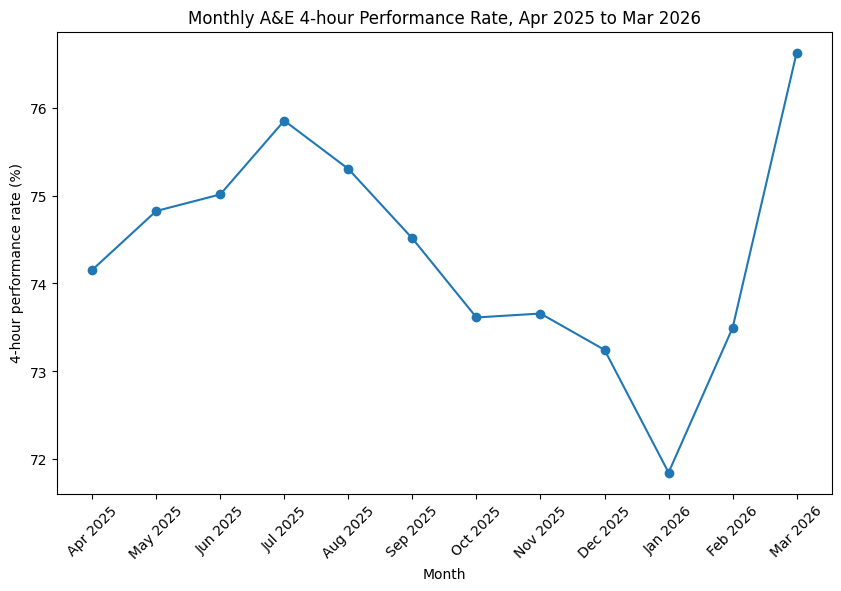

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary["period_month"],
    monthly_summary["four_hour_performance_rate"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("4-hour performance rate (%)")
plt.title("Monthly A&E 4-hour Performance Rate, Apr 2025 to Mar 2026")

plt.xticks(rotation=45)

plt.show()

The chart shows monthly changes in national A&E 4-hour performance between April 2025 and March 2026.

The 4-hour performance rate represents the percentage of patients who were admitted, transferred or discharged within four hours of arrival in A&E.

Lower performance rates may indicate increased operational pressure within urgent and emergency care services, including demand pressure, bed shortages, discharge delays and wider patient-flow challenges.

### Monthly A&E Attendance Trend

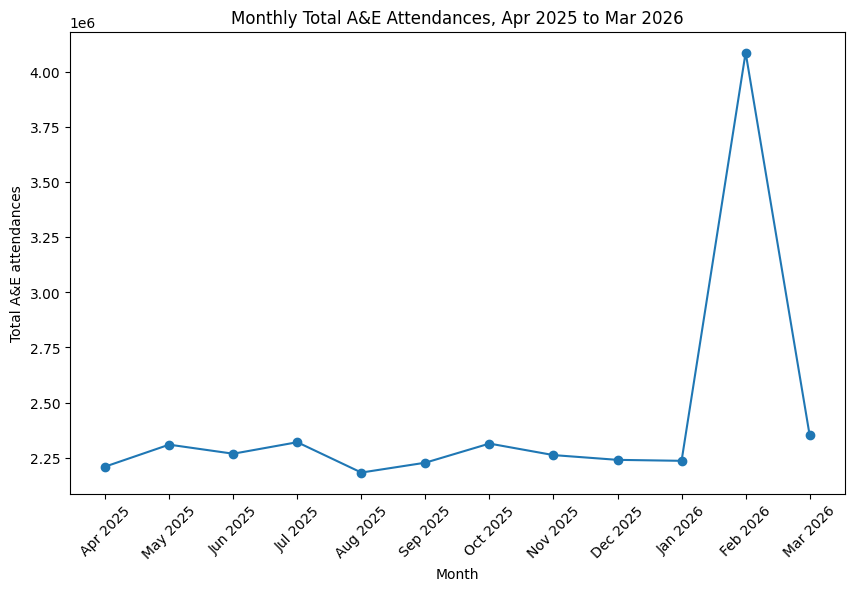

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary["period_month"],
    monthly_summary["total_ae_attendances"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total A&E attendances")
plt.title("Monthly Total A&E Attendances, Apr 2025 to Mar 2026")

plt.xticks(rotation=45)

plt.show()

The chart shows monthly total A&E attendances across England between April 2025 and March 2026.

Monitoring attendance trends is important because increases in emergency demand may place additional pressure on urgent and emergency care services. Higher attendance volumes can contribute to increased waiting times, bed pressure and operational strain across hospitals.

However, changes in performance cannot be explained by attendance volume alone. Other operational factors such as staffing, bed availability, discharge capacity and patient acuity may also influence A&E performance.

## Relationship Between Demand and 4-hour Performance

This section explores whether higher A&E attendance volumes were associated with lower 4-hour performance.

The analysis uses:
- Monthly total A&E attendances
- Monthly 4-hour performance rate

This is an exploratory analysis and does not prove causation. A&E performance may also be affected by factors such as staffing, bed availability, discharge delays, patient acuity and wider hospital flow pressures.

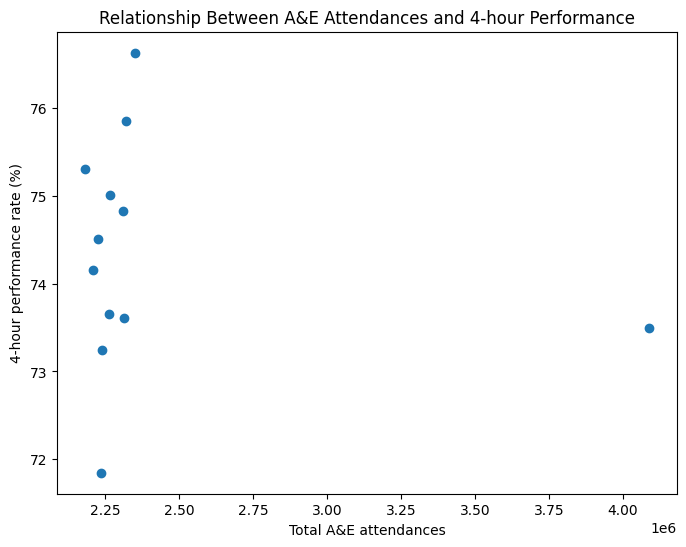

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    monthly_summary["total_ae_attendances"],
    monthly_summary["four_hour_performance_rate"]
)

plt.xlabel("Total A&E attendances")
plt.ylabel("4-hour performance rate (%)")
plt.title("Relationship Between A&E Attendances and 4-hour Performance")

plt.show()

The scatter plot compares monthly A&E demand with monthly 4-hour performance.

Each point represents one month between April 2025 and March 2026. The chart allows visual exploration of whether months with higher attendance volumes were associated with lower operational performance.

### Correlation Analysis

In [13]:
attendance_performance_correlation = monthly_summary[
    ["total_ae_attendances", "four_hour_performance_rate"]
].corr()

attendance_performance_correlation

,total_ae_attendances,four_hour_performance_rate
total_ae_attendances,1.000000,-0.167126
four_hour_performance_rate,-0.167126,1.000000


The correlation analysis showed a weak negative relationship between total A&E attendances and 4-hour performance.

This suggests that months with higher emergency demand were slightly associated with lower 4-hour performance, although the relationship was not strong.

This finding indicates that emergency demand may contribute to operational pressure, but it is unlikely to fully explain changes in A&E performance on its own. Wider operational factors such as bed availability, discharge capacity and inpatient flow are also likely to influence performance outcomes.

## Provider-Level Benchmarking Analysis

This section compares operational performance across NHS provider organisations.

Provider-level benchmarking helps identify variation in:
- 4-hour A&E performance
- Operational pressure
- Decision-to-admit waiting times
- Potential patient-flow challenges

The analysis focuses on larger providers to reduce distortion from very small services with low attendance volumes.

In [14]:
provider_summary = ae_clean.groupby("org_name").agg({
    "total_ae_attendances": "sum",
    "total_attendances_over_4hrs": "sum"
}).reset_index()

# Remove TOTAL row
provider_summary = provider_summary[
    provider_summary["org_name"] != "TOTAL"
]

# Create performance metrics
provider_summary["average_four_hour_breach_rate"] = (
    provider_summary["total_attendances_over_4hrs"] /
    provider_summary["total_ae_attendances"]
) * 100

provider_summary["average_four_hour_performance_rate"] = (
    100 - provider_summary["average_four_hour_breach_rate"]
)

# Filter larger providers only
provider_summary_filtered = provider_summary[
    provider_summary["total_ae_attendances"] >= 50000
]

# Sort lowest performance first
provider_summary_filtered = provider_summary_filtered.sort_values(
    "average_four_hour_performance_rate",
    ascending=True
)

provider_summary_filtered.head(10)

,org_name,total_ae_attendances,total_attendances_over_4hrs,average_four_hour_breach_rate,average_four_hour_performance_rate
42,EAST CHESHIRE NHS TRUST,53202,28236,53.073193,46.926807
176,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,160372,76983,48.002769,51.997231
141,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,107136,44929,41.936417,58.063583
70,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,169370,69778,41.198559,58.801441
119,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,233327,95477,40.919825,59.080175
202,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,129342,52034,40.229778,59.770222
101,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,120332,48189,40.046704,59.953296
162,SURREY AND SUSSEX HEALTHCARE NHS TRUST,127380,50172,39.387659,60.612341
29,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,92778,35799,38.585656,61.414344
164,TAMESIDE AND GLOSSOP INTEGRATED CARE NHS FOUND...,134368,51199,38.103566,61.896434


### Providers with Lowest Average 4-hour Performance

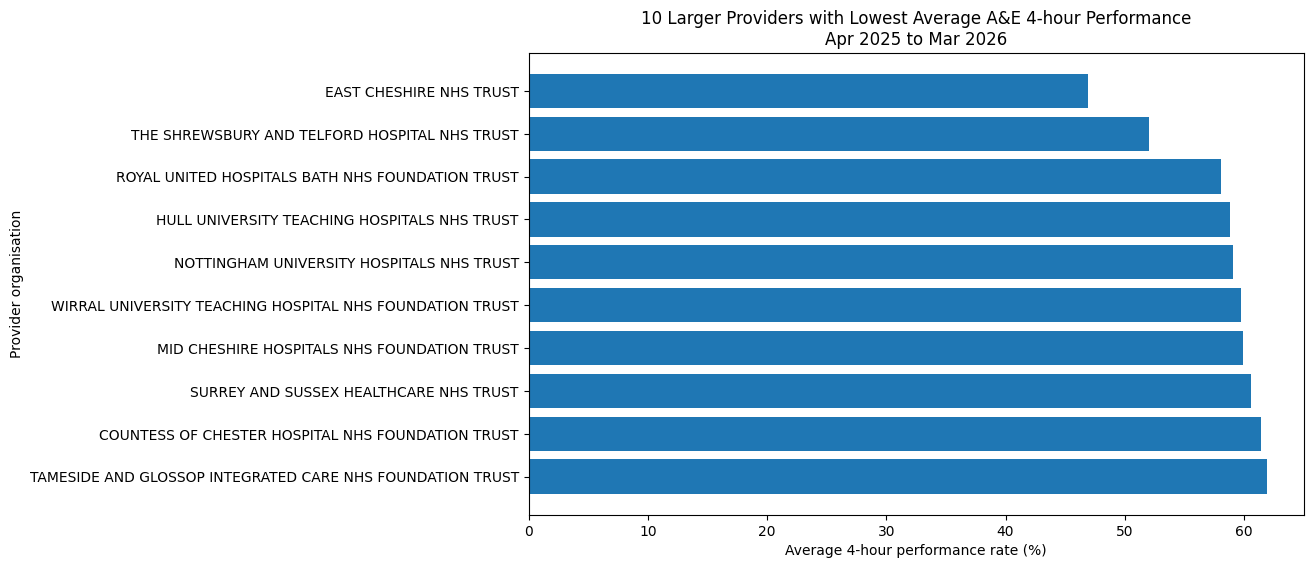

In [15]:
bottom_10_providers = provider_summary_filtered.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    bottom_10_providers["org_name"],
    bottom_10_providers["average_four_hour_performance_rate"]
)

plt.xlabel("Average 4-hour performance rate (%)")
plt.ylabel("Provider organisation")

plt.title(
    "10 Larger Providers with Lowest Average A&E 4-hour Performance\nApr 2025 to Mar 2026"
)

plt.gca().invert_yaxis()

plt.show()

The chart shows the larger provider organisations with the lowest average A&E 4-hour performance across the 12-month period.

A minimum attendance threshold was applied to reduce distortion from very small providers with low activity volumes.

Lower performance rates may reflect a combination of factors including:
- high emergency demand
- inpatient bed pressure
- discharge delays
- staffing constraints
- operational flow challenges
- patient acuity

The analysis identifies variation in operational performance but does not determine the exact causes of lower performance.

## Decision-to-Admit (DTA) Patient Flow Analysis

Decision-to-admit (DTA) waits measure patients who had already been assessed in A&E and had a clinical decision made to admit them, but were still waiting for admission.

These waits are important indicators of:
- inpatient bed pressure
- discharge delays
- hospital flow constraints
- wider operational pressure across healthcare systems

This section analyses:
- monthly DTA waiting trends
- 4–12 hour DTA waits
- 12+ hour DTA waits
- provider-level DTA variation

In [16]:
monthly_dta_summary = ae_clean.groupby("period_date").agg({
    "patients_who_have_waited_4-12_hs_from_dta_to_admission": "sum",
    "patients_who_have_waited_12+_hrs_from_dta_to_admission": "sum",
    "total_dta_waits_over_4hrs": "sum"
}).reset_index()

monthly_dta_summary["period_month"] = (
    monthly_dta_summary["period_date"]
    .dt.strftime("%b %Y")
)

monthly_dta_summary

,period_date,patients_who_have_waited_4-12_hs_from_dta_to_admission,patients_who_have_waited_12+_hrs_from_dta_to_admission,total_dta_waits_over_4hrs,period_month
0,2025-04-01,87208,44648,131856,Apr 2025
1,2025-05-01,87144,42891,130035,May 2025
2,2025-06-01,79488,38683,118171,Jun 2025
3,2025-07-01,80075,35467,115542,Jul 2025
4,2025-08-01,79917,35909,115826,Aug 2025
5,2025-09-01,84239,44765,129004,Sep 2025
6,2025-10-01,88420,54314,142734,Oct 2025
7,2025-11-01,83151,50648,133799,Nov 2025
8,2025-12-01,86988,50775,137763,Dec 2025
9,2026-01-01,89624,71517,161141,Jan 2026


### Monthly Decision-to-Admit Waiting Trends

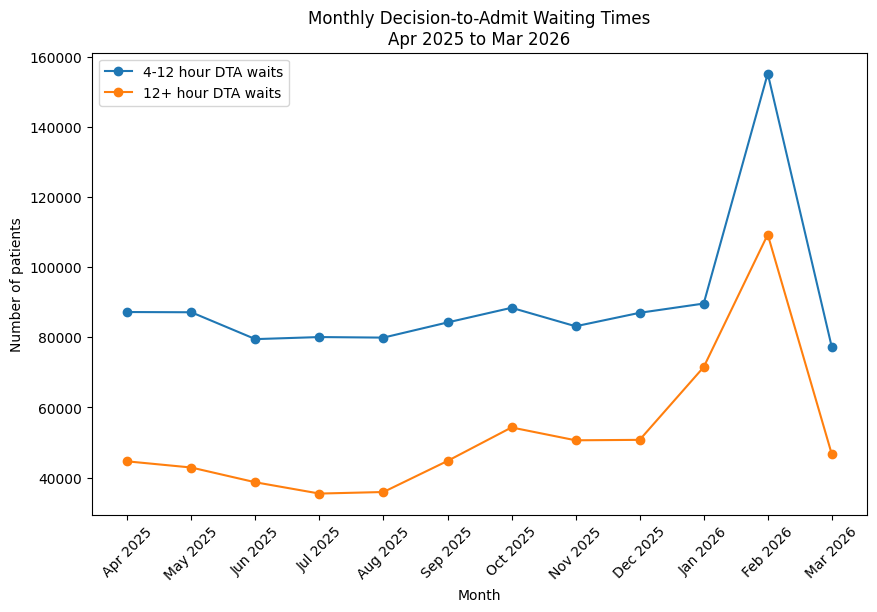

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_dta_summary["period_month"],
    monthly_dta_summary["patients_who_have_waited_4-12_hs_from_dta_to_admission"],
    marker="o",
    label="4-12 hour DTA waits"
)

plt.plot(
    monthly_dta_summary["period_month"],
    monthly_dta_summary["patients_who_have_waited_12+_hrs_from_dta_to_admission"],
    marker="o",
    label="12+ hour DTA waits"
)

plt.xlabel("Month")
plt.ylabel("Number of patients")

plt.title(
    "Monthly Decision-to-Admit Waiting Times\nApr 2025 to Mar 2026"
)

plt.xticks(rotation=45)

plt.legend()

plt.show()

The chart shows monthly trends in decision-to-admit waiting times across England.

Patients included in this measure had already received a clinical decision to admit but were still waiting for inpatient admission.

The 12+ hour DTA waits are particularly important because they may indicate severe operational pressure relating to:
- bed shortages
- delayed discharge pathways
- inpatient flow constraints
- high emergency demand
- wider hospital capacity issues

Increasing DTA waits may suggest that pressure extends beyond the emergency department itself and reflects wider whole-system patient-flow challenges.

### Total Decision-to-Admit Waits Over 4 Hours

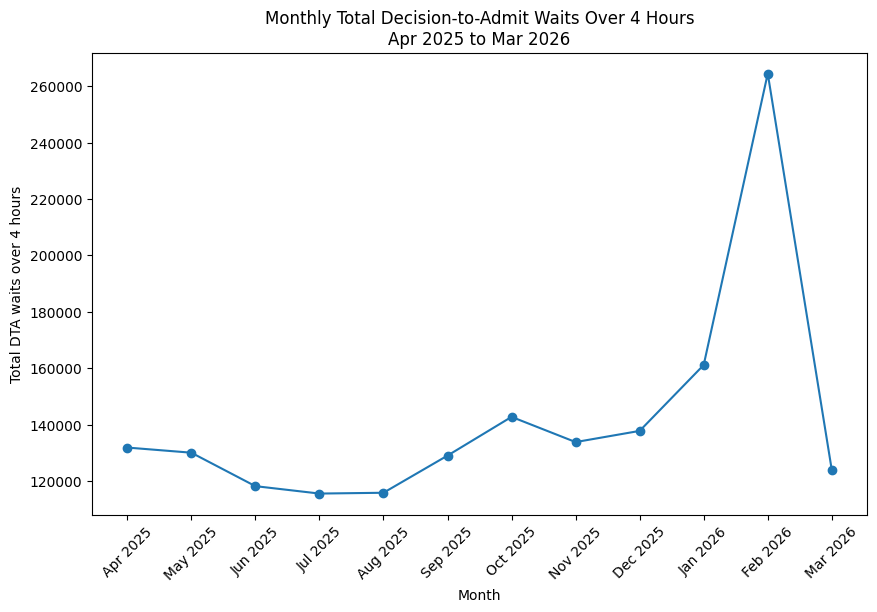

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_dta_summary["period_month"],
    monthly_dta_summary["total_dta_waits_over_4hrs"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total DTA waits over 4 hours")

plt.title(
    "Monthly Total Decision-to-Admit Waits Over 4 Hours\nApr 2025 to Mar 2026"
)

plt.xticks(rotation=45)

plt.show()

This chart combines all decision-to-admit waits over 4 hours into a single operational measure.

The metric provides an overall view of admitted-patient flow pressure across the healthcare system.

Rising DTA waits may indicate growing operational strain linked to:
- inpatient bed occupancy
- delayed discharges
- reduced flow capacity
- emergency demand pressure
- seasonal system pressures

This measure is particularly relevant to NHS operational performance and urgent care flow management.

## Provider-Level Decision-to-Admit Pressure Analysis

This section analyses variation in decision-to-admit waiting pressures across NHS provider organisations.

The analysis focuses on:
- 12+ hour DTA waits
- Provider-level variation
- Relative DTA pressure adjusted for attendance volume

This helps identify providers where admitted-patient flow pressure appeared particularly high during the 12-month period.

In [19]:
provider_dta_summary = ae_clean.groupby("org_name").agg({
    "patients_who_have_waited_4-12_hs_from_dta_to_admission": "sum",
    "patients_who_have_waited_12+_hrs_from_dta_to_admission": "sum",
    "total_dta_waits_over_4hrs": "sum",
    "total_ae_attendances": "sum"
}).reset_index()

# Remove TOTAL row
provider_dta_summary = provider_dta_summary[
    provider_dta_summary["org_name"] != "TOTAL"
]

# Sort by 12+ hour waits
provider_dta_summary = provider_dta_summary.sort_values(
    "patients_who_have_waited_12+_hrs_from_dta_to_admission",
    ascending=False
)

provider_dta_summary.head(10)

,org_name,patients_who_have_waited_4-12_hs_from_dta_to_admission,patients_who_have_waited_12+_hrs_from_dta_to_admission,total_dta_waits_over_4hrs,total_ae_attendances
137,ROYAL FREE LONDON NHS FOUNDATION TRUST,12491,22650,35141,507130
184,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,32451,21023,53474,450266
176,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,5746,16915,22661,160372
43,EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION ...,5913,14153,20066,307425
115,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,12557,13870,26427,425375
181,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,10799,13254,24053,253436
9,BARTS HEALTH NHS TRUST,13320,12837,26157,534304
44,EAST LANCASHIRE HOSPITALS NHS TRUST,5452,12747,18199,294870
204,WORCESTERSHIRE ACUTE HOSPITALS NHS TRUST,11098,12165,23263,234375
85,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,16522,11762,28284,308985


### Providers with Highest 12+ Hour DTA Waits

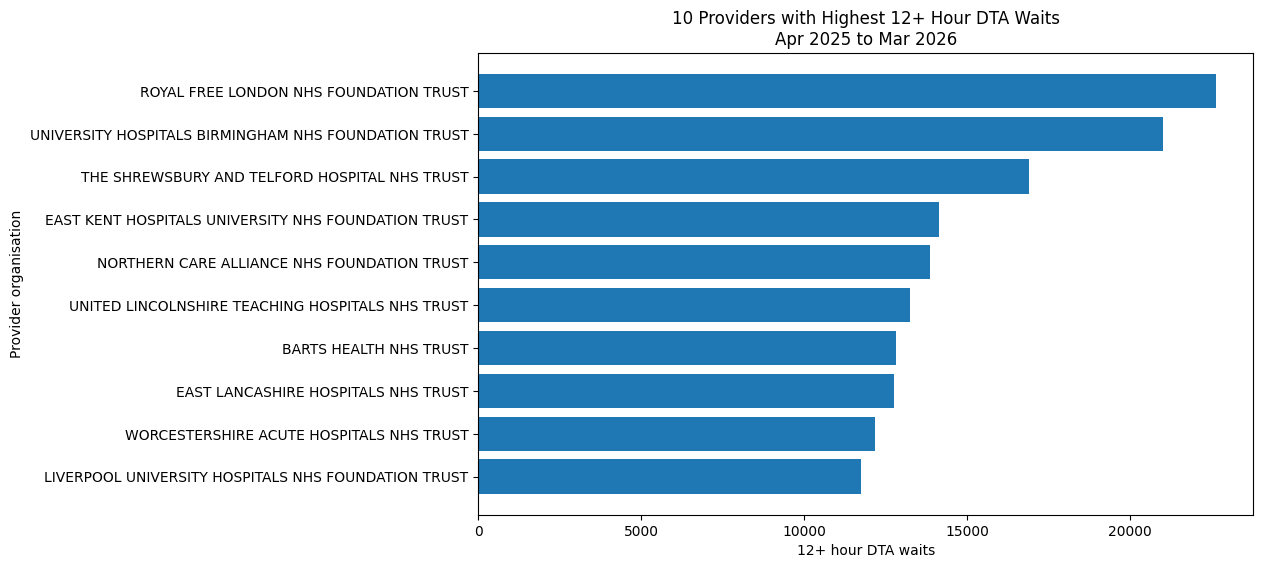

In [20]:
top_10_dta_12hr_providers = provider_dta_summary.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_dta_12hr_providers["org_name"],
    top_10_dta_12hr_providers["patients_who_have_waited_12+_hrs_from_dta_to_admission"]
)

plt.xlabel("12+ hour DTA waits")
plt.ylabel("Provider organisation")

plt.title(
    "10 Providers with Highest 12+ Hour DTA Waits\nApr 2025 to Mar 2026"
)

plt.gca().invert_yaxis()

plt.show()

The chart shows providers with the highest total number of 12+ hour decision-to-admit waits across the 12-month period.

These waits represent patients who had already received a clinical decision to admit but remained waiting for inpatient admission for over 12 hours.

Higher values may indicate:
- severe inpatient bed pressure
- delayed discharge pathways
- operational flow constraints
- capacity limitations
- wider healthcare system pressure

However, larger providers may naturally show higher counts because they manage greater patient volumes.

### Adjusted DTA Pressure Rate Analysis

In [21]:
provider_dta_summary["dta_12hr_waits_per_1000_attendances"] = (
    provider_dta_summary["patients_who_have_waited_12+_hrs_from_dta_to_admission"] /
    provider_dta_summary["total_ae_attendances"]
) * 1000

# Filter larger providers
provider_dta_summary_rate = provider_dta_summary[
    provider_dta_summary["total_ae_attendances"] >= 50000
]

# Sort highest rates first
provider_dta_summary_rate = provider_dta_summary_rate.sort_values(
    "dta_12hr_waits_per_1000_attendances",
    ascending=False
)

provider_dta_summary_rate.head(10)

,org_name,patients_who_have_waited_4-12_hs_from_dta_to_admission,patients_who_have_waited_12+_hrs_from_dta_to_admission,total_dta_waits_over_4hrs,total_ae_attendances,dta_12hr_waits_per_1000_attendances
176,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,5746,16915,22661,160372,105.473524
196,WARRINGTON AND HALTON TEACHING HOSPITALS NHS F...,7893,10072,17965,118419,85.053919
29,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,4735,7784,12519,92778,83.899200
42,EAST CHESHIRE NHS TRUST,2566,4105,6671,53202,77.158753
202,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,6310,9311,15621,129342,71.987444
127,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,10092,11685,21777,176501,66.203591
49,EPSOM AND ST HELIER UNIVERSITY HOSPITALS NHS T...,7771,9944,17715,158195,62.859130
162,SURREY AND SUSSEX HEALTHCARE NHS TRUST,6482,7748,14230,127380,60.825875
114,NORTHAMPTON GENERAL HOSPITAL NHS TRUST,6683,8672,15355,157573,55.034809
101,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,5881,6447,12328,120332,53.576771


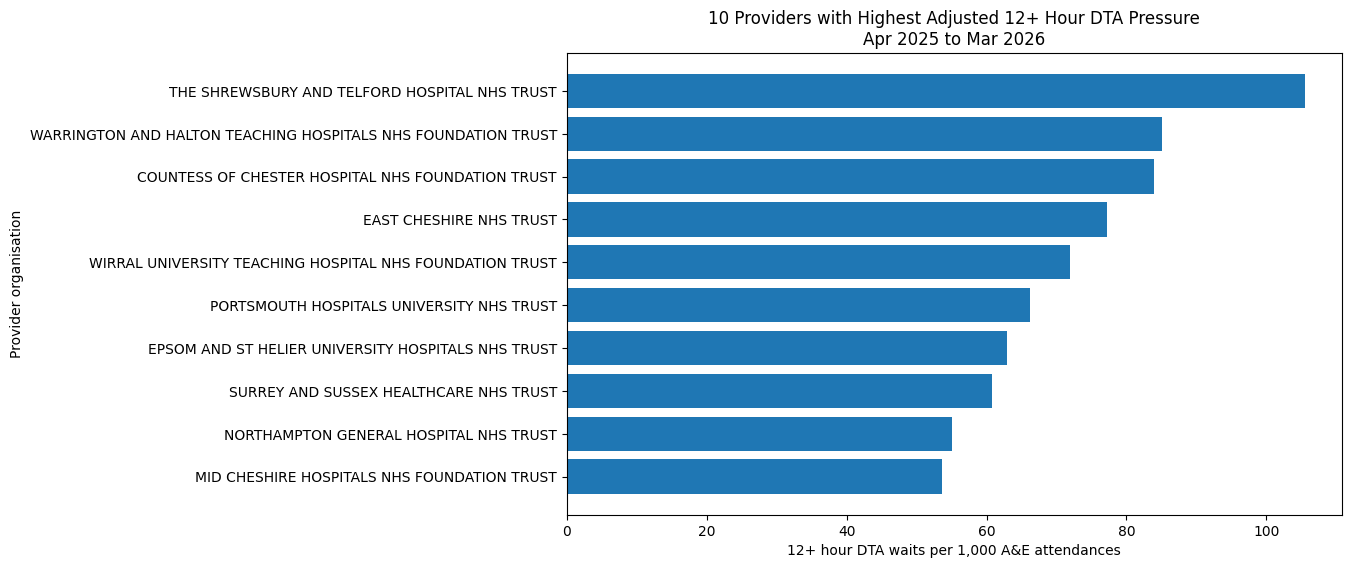

In [22]:
top_10_dta_rate_providers = provider_dta_summary_rate.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_dta_rate_providers["org_name"],
    top_10_dta_rate_providers["dta_12hr_waits_per_1000_attendances"]
)

plt.xlabel("12+ hour DTA waits per 1,000 A&E attendances")
plt.ylabel("Provider organisation")

plt.title(
    "10 Providers with Highest Adjusted 12+ Hour DTA Pressure\nApr 2025 to Mar 2026"
)

plt.gca().invert_yaxis()

plt.show()

This adjusted analysis accounts for provider size by calculating 12+ hour DTA waits per 1,000 A&E attendances.

The adjusted metric provides a fairer comparison between providers because larger hospitals naturally manage higher patient volumes.

Higher adjusted DTA pressure rates may indicate:
- relatively greater operational strain
- reduced inpatient flow capacity
- bed availability constraints
- delayed discharge pressures
- sustained system-level demand pressure

This type of adjusted operational benchmarking is useful for identifying providers experiencing proportionally higher admitted-patient flow pressure.

## Key Findings

1. National A&E performance remained under operational pressure across the 12-month period.

2. Monthly attendance volumes fluctuated throughout the year, indicating changing emergency demand patterns across NHS services.

3. Higher attendance volumes showed a weak negative relationship with 4-hour performance, suggesting that demand pressure may contribute to operational strain but does not fully explain performance variation.

4. Significant variation existed between provider organisations in both 4-hour performance and decision-to-admit waiting times.

5. Several providers demonstrated substantially higher levels of 12+ hour decision-to-admit waits, indicating potential inpatient flow and bed-capacity pressures.

6. Adjusted DTA pressure analysis showed that some providers experienced proportionally higher admitted-patient flow pressure even after accounting for attendance volume.

7. The findings suggest that wider operational factors beyond emergency attendance demand may influence urgent and emergency care performance.

## Limitations

1. The analysis used aggregated provider-level operational data and did not include patient-level information.

2. The project focused on national monthly operational reporting and therefore could not assess individual patient outcomes or case complexity.

3. The analysis was exploratory and does not demonstrate causal relationships between attendance demand and operational performance.

4. Additional operational variables such as staffing levels, bed occupancy, discharge capacity and workforce pressures were not included in the dataset.

5. Some provider variation may reflect differences in local population demand, hospital size, specialist services and regional healthcare pressures.

## Recommendations

1. Future analysis could incorporate bed occupancy, discharge delays and staffing data to better understand operational flow pressures.

2. Patient-level analysis could provide more detailed insight into pathways associated with prolonged waits and delayed admissions.

3. Additional seasonal trend analysis may help identify recurring periods of operational pressure.

4. Provider benchmarking could be expanded by comparing organisations with similar size, demand and service profiles.

5. Interactive dashboards using tools such as Power BI could support operational monitoring and executive reporting.

## Conclusion

This project analysed NHS England A&E operational data between April 2025 and March 2026 to explore emergency demand, 4-hour performance and decision-to-admit waiting pressures.

The analysis demonstrated how healthcare operational data can be used to investigate urgent and emergency care performance, patient-flow challenges and provider-level variation across NHS organisations.

The findings suggest that operational performance is influenced by a combination of emergency demand and wider hospital flow pressures, including admitted-patient delays and inpatient capacity constraints.

This project demonstrates practical healthcare analytics skills including:
- data cleaning
- operational KPI development
- provider benchmarking
- trend analysis
- healthcare data interpretation
- patient-flow analysis
- visualisation and reporting

## Tools and Technologies Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- NHS England Open Data
- Healthcare Operational Analytics
- Patient Flow Analysis